# Predicción de Partidos del Mundial - Fase 1
Este notebook carga datos reales, agrupa equipos con aprendizaje no supervisado y entrena un modelo supervisado para predecir marcadores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [2]:
# Cargar el dataset real
df = pd.read_csv('../data/raw/real_results.csv')
# Filtrar para usar datos más modernos (ej. desde el año 2000 en adelante)
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year >= 2000].copy()
print(f"Total de partidos recientes: {len(df)}")
df.head()

Total de partidos recientes: 25441


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
24062,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False
24063,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False
24064,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False
24065,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False
24066,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True


## 2. Aprendizaje No Supervisado: Agrupación de Equipos (Clustering)
Vamos a agrupar a las selecciones en 'Tiers' (Niveles) usando **K-Means** basándonos en su rendimiento histórico (Goles promedio y Ratio de victorias).

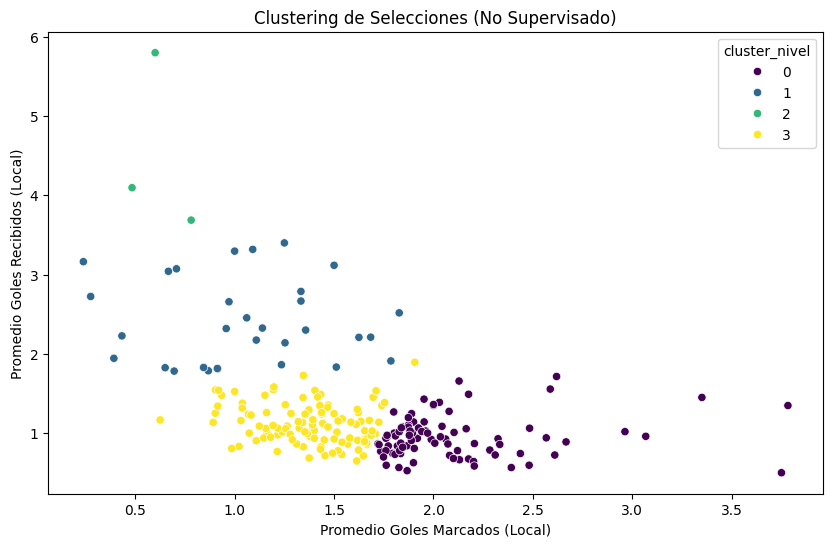

In [3]:
# Calcular estadísticas por equipo (como Local)
home_stats = df.groupby('home_team').agg(
    goles_marcados=('home_score', 'mean'),
    goles_recibidos=('away_score', 'mean'),
    partidos=('home_score', 'count')
).reset_index().rename(columns={'home_team': 'team'})

# Filtramos equipos con pocos partidos
home_stats = home_stats[home_stats['partidos'] >= 20]

# K-Means Clustering (No supervisado)
kmeans = KMeans(n_clusters=4, random_state=42)
features = home_stats[['goles_marcados', 'goles_recibidos']]
home_stats['cluster_nivel'] = kmeans.fit_predict(features)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=home_stats, x='goles_marcados', y='goles_recibidos', hue='cluster_nivel', palette='viridis')
plt.title('Clustering de Selecciones (No Supervisado)')
plt.xlabel('Promedio Goles Marcados (Local)')
plt.ylabel('Promedio Goles Recibidos (Local)')
plt.show()

## 3. Preparación de Datos para el Modelo Supervisado

In [4]:
# Unir los clusters al dataframe original como nuevas características
team_clusters = dict(zip(home_stats['team'], home_stats['cluster_nivel']))
df['home_cluster'] = df['home_team'].map(team_clusters).fillna(2) # Default cluster
df['away_cluster'] = df['away_team'].map(team_clusters).fillna(2)

# ---> AGREGA ESTA LÍNEA AQUÍ PARA ELIMINAR LOS NULOS <---
df = df.dropna(subset=['home_score', 'away_score'])

# Simplificamos los goles altos
df['home_score_capped'] = df['home_score'].clip(upper=5)
df['away_score_capped'] = df['away_score'].clip(upper=5)

X = df[['home_team', 'away_team', 'home_cluster', 'away_cluster', 'neutral']]
y_home = df['home_score_capped']
y_away = df['away_score_capped']


## 4. Aprendizaje Supervisado: Entrenando Random Forest
Aquí usamos las respuestas correctas (goles reales) para predecir futuros partidos.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['home_team', 'away_team'])
    ],
    remainder='passthrough'
)

# Modelo Goles Local
home_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Modelo Goles Visitante
away_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

print("Entrenando modelos...")
home_model.fit(X, y_home)
away_model.fit(X, y_away)
print("¡Entrenamiento completado!")

Entrenando modelos...


¡Entrenamiento completado!


## 5. Predicción (Interfaz Interactiva)
Cambia los equipos en la celda de abajo y ejecútala para ver el resultado más probable.

In [6]:
# ¡Prueba tú mismo!
EQUIPO_A = "Portugal"
EQUIPO_B = "España"

# Encontrar clusters
cluster_a = team_clusters.get(EQUIPO_A, 2)
cluster_b = team_clusters.get(EQUIPO_B, 2)

input_data = pd.DataFrame([{
    'home_team': EQUIPO_A,
    'away_team': EQUIPO_B,
    'home_cluster': cluster_a,
    'away_cluster': cluster_b,
    'neutral': True
}])

probs_home = home_model.predict_proba(input_data)[0]
probs_away = away_model.predict_proba(input_data)[0]
classes_home = home_model.classes_
classes_away = away_model.classes_

import numpy as np
joint_probs = np.outer(probs_home, probs_away)
max_idx = np.unravel_index(np.argmax(joint_probs), joint_probs.shape)

pred_h = classes_home[max_idx[0]]
pred_a = classes_away[max_idx[1]]
prob_max = joint_probs[max_idx]

print(f"⚽ PREDICCIÓN: {EQUIPO_A} vs {EQUIPO_B}")
print(f"🎯 Resultado más probable: {EQUIPO_A} {pred_h} - {pred_a} {EQUIPO_B} ({prob_max*100:.1f}%)")

⚽ PREDICCIÓN: Portugal vs España
🎯 Resultado más probable: Portugal 1.0 - 0.0 España (11.5%)


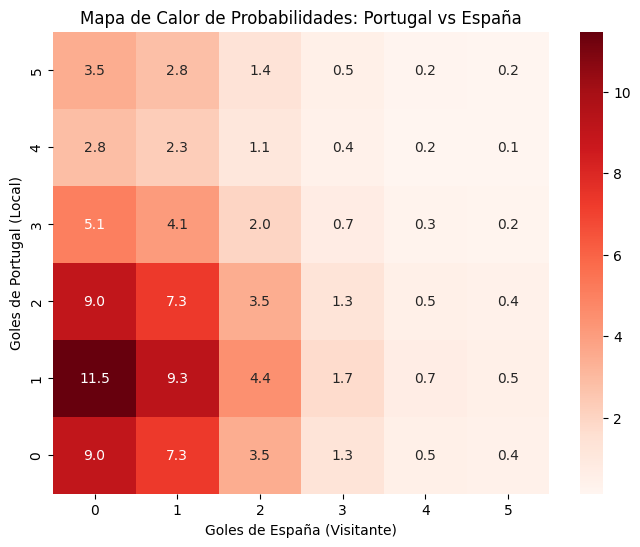

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(joint_probs * 100, 
            annot=True, 
            fmt=".1f", 
            cmap="Reds", 
            xticklabels=[int(c) for c in classes_away], 
            yticklabels=[int(c) for c in classes_home])

plt.title(f"Mapa de Calor de Probabilidades: {EQUIPO_A} vs {EQUIPO_B}")
plt.xlabel(f"Goles de {EQUIPO_B} (Visitante)")
plt.ylabel(f"Goles de {EQUIPO_A} (Local)")
plt.gca().invert_yaxis()
plt.show()